## 05 - XLM-RoBERTa Fine-tuning for Hate Speech Detection

This notebook fine-tunes XLM-RoBERTa for binary hate speech classification in Spanish (Phase 1).

The notebook is run on a GCP VM instance (n1-standard-4, NVIDIA Tesla T4 GPU, 
europe-west4-b) rather than locally, due to the computational requirements of 
fine-tuning a 278M parameter model. PyTorch 2.6.0+cu124 is used to ensure 
compatibility with the VM's CUDA 12.8 environment.

The pipeline is:
1. Load processed splits from GCP
2. Tokenization with XLM-RoBERTa tokenizer
3. PyTorch Dataset and DataLoader setup
4. Custom classification head definition (768 → 256 → 2)
5. Coarse hyperparameter search with Optuna (10 trials, 2 epochs each)
6. Fine-tuning with best parameters
7. Evaluation on validation and test sets
8. Comparison with traditional ML baseline
9. Save model to GCP

In [1]:
# ======================================= #
# 05_xlm_roberta.ipynb                    #
# XLM-RoBERTa fine-tuning for hate speech #
# binary classification (Phase 1)         #
# ======================================= #

# Basic manipulation
import os
import sys
import numpy as np
import pandas as pd
from google.cloud import storage
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'src')))

# Reproducibility
from utils import set_seed
SEED = 42
set_seed(SEED)

# Deep learning
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

# Evaluation
from sklearn.metrics import (
    f1_score,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score
)

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Device detection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"\nImports OK")
print(f"PyTorch version: {torch.__version__}")

/home/txellsupercapi/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Device: cuda
GPU: NVIDIA L4
Memory: 23.7 GB

Imports OK
PyTorch version: 2.6.0+cu124


## 1. Load Processed Splits from GCP

The three splits are loaded directly from the `sinodio-processed-data` bucket,
where they were stored during preprocessing as Parquet files. We use the `text_clean`
column — the minimally cleaned version — rather than `text_tfidf`, since XLM-RoBERTa
benefits from punctuation, accents and case information that the deeper cleaning strips out.

DataFrames are named with the `_df` suffix to avoid naming conflicts with the PyTorch
Dataset and DataLoader objects defined later in the notebook.

In [2]:
# ============================== #
# Load processed splits from GCP #
# ============================== #

GCS_PROCESSED_BUCKET = 'sinodio-processed-data'

client = storage.Client()
bucket = client.bucket(GCS_PROCESSED_BUCKET)

def load_parquet_from_gcs(bucket, blob_name):
    blob = bucket.blob(blob_name)
    data = blob.download_as_bytes()
    return pd.read_parquet(pd.io.common.BytesIO(data))

train_df = load_parquet_from_gcs(bucket, 'phase1/train.parquet')
val_df   = load_parquet_from_gcs(bucket, 'phase1/val.parquet')
test_df  = load_parquet_from_gcs(bucket, 'phase1/test.parquet')

print(f"Train: {train_df.shape}")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")

print(f"\nColumns: {train_df.columns.tolist()}")

Train: (41245, 5)
Val:   (7279, 5)
Test:  (8564, 5)

Columns: ['text', 'label', 'source', 'text_clean', 'text_tfidf']


## 2. Tokenization

XLM-RoBERTa uses a SentencePiece tokenizer with a vocabulary of 250,002 subword tokens,
trained on 100 languages. The tokenizer converts raw text into two tensors:

- `input_ids`: the tokenized text as a sequence of integer indices into the vocabulary.
  Special tokens are included: `[CLS]` at position 0 (used for classification) and 
  `[SEP]` at the end.
- `attention_mask`: a sequence of 1s and 0s indicating which tokens are real (1) and
  which are padding (0), so the model does not attend to padding tokens.

`MAX_LENGTH=128` was chosen based on the text length distribution identified in the EDA:
the median text length is approximately 100 characters, and the estimated truncation rate
at 128 tokens is only 0.3%, meaning virtually no information is lost by this choice.
XLM-RoBERTa supports up to 512 tokens, but using 128 significantly reduces memory usage
and training time with negligible impact on the data.

The tokenizer is downloaded from HuggingFace Hub on first use and cached locally.

In [3]:
# ============ #
# Tokenization #
# ============ #

MODEL_NAME = 'xlm-roberta-base'
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts, tokenizer, max_length):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

train_encodings = tokenize(train_df['text_clean'], tokenizer, MAX_LENGTH)
val_encodings   = tokenize(val_df['text_clean'],   tokenizer, MAX_LENGTH)
test_encodings  = tokenize(test_df['text_clean'],  tokenizer, MAX_LENGTH)

print(f"Tokenization complete.")
print(f"Input IDs shape (train): {train_encodings['input_ids'].shape}")
print(f"MAX_LENGTH: {MAX_LENGTH} tokens")

# Verify impact of truncation
lengths = [len(tokenizer.encode(t)) for t in train_df['text_clean'].sample(1000, random_state=SEED)]
truncated = sum(1 for l in lengths if l > MAX_LENGTH)
print(f"\nEstimated truncation rate (sample of 1000): {truncated/10:.1f}%")

Token indices sequence length is longer than the specified maximum sequence length for this model (564 > 512). Running this sequence through the model will result in indexing errors


Tokenization complete.
Input IDs shape (train): torch.Size([41245, 128])
MAX_LENGTH: 128 tokens

Estimated truncation rate (sample of 1000): 0.3%


## 3. PyTorch Dataset

A custom `HateSpeechDataset` class wraps the tokenized encodings and labels into a
PyTorch Dataset object, which handles batching and shuffling during training. Each item
returned by the dataset is a dictionary containing `input_ids`, `attention_mask` and
`labels`, with all tensors moved directly to the GPU via `.to(device)`.

In [4]:
# ===================== #
# PyTorch Dataset class #
# ===================== #

from torch.utils.data import Dataset, DataLoader

class HateSpeechDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: val[idx].to(device)
            for key, val in self.encodings.items()
        }
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long).to(device)
        return item

# --- Create datasets ---
train_dataset = HateSpeechDataset(train_encodings, train_df['label'].values)
val_dataset   = HateSpeechDataset(val_encodings,   val_df['label'].values)
test_dataset  = HateSpeechDataset(test_encodings,  test_df['label'].values)

print(f"Train dataset: {len(train_dataset)} examples")
print(f"Val dataset:   {len(val_dataset)} examples")
print(f"Test dataset:  {len(test_dataset)} examples")

# Verify with just one batch
sample = train_dataset[0]
print(f"\nSample keys: {list(sample.keys())}")
print(f"input_ids shape: {sample['input_ids'].shape}")
print(f"label: {sample['labels']}")

Train dataset: 41245 examples
Val dataset:   7279 examples
Test dataset:  8564 examples

Sample keys: ['input_ids', 'attention_mask', 'labels']
input_ids shape: torch.Size([128])
label: 1


## 4. Model Definition: XLM-RoBERTa + Custom Classification Head

The model consists of two components:

**XLM-RoBERTa base**: the pre-trained transformer backbone with 12 attention layers,
hidden size of 768, and ~278M parameters. It processes the tokenized input and produces
a contextual representation for each token.

**Custom classification head**: instead of the standard single linear layer (768 → 2),
we define a two-layer head (768 → 256 → 2) with ReLU activation and dropout. This gives
the model more capacity to learn hate speech-specific representations before the final
classification, which tends to improve performance on domain-specific tasks.

The `[CLS]` token at position 0 of the last hidden state is used as the sequence
representation — this is the standard approach for classification tasks with RoBERTa-based
models, equivalent to using the flattened feature map from a CNN for image classification.

Dropout (p=0.3) is applied twice — before the hidden layer and before the classifier —
to regularize both transitions and reduce overfitting.

The model has 278,241,026 trainable parameters and is moved to the GPU for training.

In [5]:
# ========================= #
# Model definition          #
# XLM-RoBERTa + custom head #
# 768 → 256 → 2             #
# ========================= #

from transformers import AutoModel
from torch import nn

class HateSpeechClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.3):
        super(HateSpeechClassifier, self).__init__()
        self.roberta   = AutoModel.from_pretrained(model_name)
        self.dropout   = nn.Dropout(dropout)
        self.hidden    = nn.Linear(768, 256)
        self.relu      = nn.ReLU()
        self.classifier = nn.Linear(256, 2)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs     = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output  = outputs.last_hidden_state[:, 0, :]  # [CLS] token (pos. 0) for each batch example, giving a 768-dimensional vector per example
        x           = self.dropout(cls_output)  # Dropout is applied to regularize transitions before hidden layer
        x           = self.hidden(x)
        x           = self.relu(x)
        x           = self.dropout(x)   # Dropout is applied to regularize transitions before classifier
        logits      = self.classifier(x)
        return logits

# Instantiate and move to device
model = HateSpeechClassifier(MODEL_NAME).to(device)

# Verify model architecture
print(model)
print(f"\nModel moved to: {next(model.parameters()).device}")

# Count trainable parameters (to get a sense of model size)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HateSpeechClassifier(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
   

## 5. Coarse Hyperparameter Search with Optuna

A coarse hyperparameter search is performed before full fine-tuning to identify the
most promising region of the hyperparameter space efficiently. Each trial trains for
only 2 epochs, which is sufficient to distinguish good configurations from poor ones
without the cost of full training.

Search space:
- `learning_rate`: log-uniform between 1e-5 and 5e-5 —> the standard range for
  transformer fine-tuning; values outside this range tend to cause instability
- `batch_size`: 16, 32 or 64 —> larger batches are faster but may reduce generalization
- `warmup_ratio`: uniform between 0.0 and 0.2 —> the proportion of training steps
  used for linear learning rate warm-up, which stabilizes early training

The objective function maximizes macro F1 on the validation set, consistent with
the evaluation strategy used throughout the project. GPU memory is explicitly freed
after each trial using `torch.cuda.empty_cache()` and `gc.collect()` to prevent
memory accumulation across trials.

`tqdm` progress bars are used to monitor training and evaluation in real time,
providing batch-level loss updates and estimated time remaining per epoch. This
addresses a limitation identified during Random Forest tuning, where the absence
of progress feedback made it impossible to estimate training time.

10 trials with a timeout of 120 minutes.

In [6]:
# ======================== #
# Optuna coarse search     #
# 10 trials, 2 epochs each #
# ======================== #

from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score
from tqdm import tqdm
import gc

def train_epoch(model, dataloader, optimizer, scheduler, epoch, trial_num):
    model.train()
    total_loss = 0
    criterion  = nn.CrossEntropyLoss()
    
    progress_bar = tqdm(dataloader, desc=f"Trial {trial_num} | Epoch {epoch+1} | Training")
    
    for batch in progress_bar:
        optimizer.zero_grad()
        input_ids      = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels         = batch['labels']
        
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(dataloader)

def evaluate(model, dataloader, desc="Evaluating"):
    model.eval()
    all_preds  = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc=desc)
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids      = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels         = batch['labels']
            
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            preds  = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return f1_score(all_labels, all_preds, average='macro')

def objective_xlm(trial):
    # --- Hyperparameter search space ---
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 5e-5, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64])
    warmup_ratio  = trial.suggest_float('warmup_ratio', 0.0, 0.2)
    
    print(f"\nTrial {trial.number} | lr={learning_rate:.2e} | batch={batch_size} | warmup={warmup_ratio:.3f}")
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    
    # --- Model, optimizer, scheduler ---
    trial_model = HateSpeechClassifier(MODEL_NAME).to(device)
    optimizer   = AdamW(trial_model.parameters(), lr=learning_rate, weight_decay=0.01)
    
    total_steps  = len(train_loader) * 2  # 2 epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler    = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    
    # --- Train for 2 epochs ---
    for epoch in range(2):
        train_loss = train_epoch(trial_model, train_loader, optimizer, scheduler, epoch, trial.number)
        val_f1     = evaluate(trial_model, val_loader, desc=f"Trial {trial.number} | Epoch {epoch+1} | Evaluating")
        print(f"  → Epoch {epoch+1} complete | Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")
    
    # --- Clean up to free GPU memory ---
    del trial_model
    torch.cuda.empty_cache()
    gc.collect()
    
    return val_f1

# --- Run coarse search ---
study_xlm = optuna.create_study(direction='maximize')
study_xlm.optimize(objective_xlm, n_trials=10, timeout=7200)

# --- Save best results ---
import json
best_results = {
    'best_params': study_xlm.best_params,
    'best_value': study_xlm.best_value
}
with open('optuna_coarse_results.json', 'w') as f:
    json.dump(best_results, f, indent=2)
print(f"Results saved to optuna_coarse_results.json")

print(f"\nBest parameters: {study_xlm.best_params}")
print(f"Best macro F1 (val): {study_xlm.best_value:.4f}")


Trial 0 | lr=1.16e-05 | batch=64 | warmup=0.168


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Trial 0 | Epoch 1 | Training: 100%|█████████████████████████████| 645/645 [06:44<00:00,  1.60it/s, loss=0.2862]
Trial 0 | Epoch 1 | Evaluating: 100%|████████████████████████████████████████| 114/114 [00:23<00:00,  4.95it/s]


  → Epoch 1 complete | Loss: 0.5280 | Val F1: 0.7629


Trial 0 | Epoch 2 | Training: 100%|█████████████████████████████| 645/645 [06:50<00:00,  1.57it/s, loss=0.4553]
Trial 0 | Epoch 2 | Evaluating: 100%|████████████████████████████████████████| 114/114 [00:23<00:00,  4.95it/s]


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Trial 6 | Epoch 1 | Training: 100%|███████████████████████████| 2578/2578 [10:18<00:00,  4.17it/s, loss=0.2681]
Trial 6 | Epoch 1 | Evaluating: 100%|████████████████████████████████████████| 455/455 [00:22<00:00, 19.83it/s]


  → Epoch 1 complete | Loss: 0.4862 | Val F1: 0.7634


Trial 6 | Epoch 2 | Training: 100%|███████████████████████████| 2578/2578 [10:18<00:00,  4.17it/s, loss=0.1568]
Trial 6 | Epoch 2 | Evaluating: 100%|████████████████████████████████████████| 455/455 [00:22<00:00, 20.39it/s]


  → Epoch 2 complete | Loss: 0.3633 | Val F1: 0.7951
Results saved to optuna_coarse_results.json

Best parameters: {'learning_rate': 4.411436814046886e-05, 'batch_size': 32, 'warmup_ratio': 0.14293057914810742}
Best macro F1 (val): 0.8097


## 6. Training and Evaluation Functions (already used in coarse-tuning above)

The helper functions used by the Optuna coarse search above are rewritten here since the VM had to be restarted and there is no need for running the coarse-tuning of hyperparameters again. Next they will be used for evaluating the full fine-tuning of hyperparameters. They should have been in a separate cell anyway.

- `train_epoch`: runs one full pass over the training set, computing loss and updating 
  weights via backpropagation. Gradient clipping (`max_norm=1.0`) is applied to prevent 
  exploding gradients, which is standard practice for transformer fine-tuning.
- `evaluate`: runs inference over a dataloader and returns macro F1 on the predictions.

Both functions use `tqdm` progress bars to monitor training in real time, addressing a limitation identified during Random Forest tuning in the baseline notebook, where the absence of progress feedback made it difficult to estimate training time. Here the progress bars provide batch-level loss updates and estimated time remaining per epoch.

In [8]:
# ================================= #
# Training and evaluation functions #
# (redefined here to avoid having   #
# to run coarse-tuning cell again   #
# ================================= #

from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score
from tqdm import tqdm
import gc

def train_epoch(model, dataloader, optimizer, scheduler, epoch, trial_num):
    model.train()
    total_loss = 0
    criterion  = nn.CrossEntropyLoss()
    
    progress_bar = tqdm(dataloader, desc=f"Trial {trial_num} | Epoch {epoch+1} | Training")
    
    for batch in progress_bar:
        optimizer.zero_grad()
        input_ids      = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels         = batch['labels']
        
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(dataloader)

def evaluate(model, dataloader, desc="Evaluating"):
    model.eval()
    all_preds  = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc=desc)
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids      = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels         = batch['labels']
            
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            preds  = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return f1_score(all_labels, all_preds, average='macro')

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## 7. Full Fine-tuning with Best Parameters

The best hyperparameters identified by the coarse search are loaded from `optuna_coarse_results.json` and used to fine-tune the model for 5 full epochs over the entire training set.

Key decisions:
- `N_EPOCHS=5`: enough for full convergence based on the loss curve observed during 
  the coarse search, where Val F1 plateaued after 4-5 epochs
- `weight_decay=0.01`: L2 regularization applied via AdamW to reduce overfitting
- **Checkpointing**: the best model checkpoint is saved to disk after each epoch that improves Val F1, so training can be resumed if the VM is interrupted. This is an important safety measure, given the Spot VM issues experienced earlier in the project, as well as the laptop going to sleep after a certain period of "inactivity".
- **Linear warmup scheduler**: the learning rate increases linearly during the warmup steps and then decays linearly to zero, which stabilizes early training and is the standard approach for transformer fine-tuning.

In [6]:
# ======================================== #
# Check for coarse-tuning best params file #
# ======================================== #

import json
with open('optuna_coarse_results.json', 'r') as f:
    print(json.load(f))

{'best_params': {'learning_rate': 4.411436814046886e-05, 'batch_size': 32, 'warmup_ratio': 0.14293057914810742}, 'best_value': 0.8096762532184908}


In [9]:
# ================================= #
# Full fine-tuning with best params #
# ================================= #

import json
import os

# --- Load best parameters ---
with open('optuna_coarse_results.json', 'r') as f:
    best_results = json.load(f)

best_params = best_results['best_params']
print(f"Fine-tuning with best parameters:")
print(f"  learning_rate: {best_params['learning_rate']:.2e}")
print(f"  batch_size:    {best_params['batch_size']}")
print(f"  warmup_ratio:  {best_params['warmup_ratio']:.3f}")

# --- Configuration ---
N_EPOCHS   = 5
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=best_params['batch_size'], shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=best_params['batch_size'], shuffle=False)

# --- Model, optimizer, scheduler ---
final_model = HateSpeechClassifier(MODEL_NAME).to(device)
optimizer   = AdamW(final_model.parameters(), 
                    lr=best_params['learning_rate'], 
                    weight_decay=0.01)

total_steps  = len(train_loader) * N_EPOCHS
warmup_steps = int(total_steps * best_params['warmup_ratio'])
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# --- Training loop with checkpointing ---
best_val_f1    = 0
best_epoch     = 0
training_log   = []

print(f"\nTraining for {N_EPOCHS} epochs...")
print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")

for epoch in range(N_EPOCHS):
    train_loss = train_epoch(final_model, train_loader, optimizer, scheduler, epoch, 'final')
    val_f1     = evaluate(final_model, val_loader, desc=f"Epoch {epoch+1} | Evaluating")
    
    training_log.append({
        'epoch':      epoch + 1,
        'train_loss': round(train_loss, 4),
        'val_f1':     round(val_f1, 4)
    })
    
    print(f"\n→ Epoch {epoch+1}/{N_EPOCHS} | Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")
    
    # --- Save checkpoint if best ---
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch + 1
        torch.save({
            'epoch':       epoch + 1,
            'model_state': final_model.state_dict(),
            'optimizer':   optimizer.state_dict(),
            'val_f1':      val_f1
        }, f'{CHECKPOINT_DIR}/best_model.pt')
        print(f"  ✓ New best model saved (Val F1: {val_f1:.4f})")

print(f"\nTraining complete.")
print(f"Best Val F1: {best_val_f1:.4f} at epoch {best_epoch}")
print(f"\nTraining log:")
for entry in training_log:
    print(f"  Epoch {entry['epoch']} | Loss: {entry['train_loss']} | Val F1: {entry['val_f1']}")

Fine-tuning with best parameters:
  learning_rate: 4.41e-05
  batch_size:    32
  warmup_ratio:  0.143


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training for 5 epochs...
Total steps: 6445 | Warmup steps: 921


Trial final | Epoch 1 | Training: 100%|███████████████████████| 1289/1289 [07:43<00:00,  2.78it/s, loss=0.4677]
Epoch 1 | Evaluating: 100%|██████████████████████████████████████████████████| 228/228 [00:21<00:00, 10.69it/s]


...


→ Epoch 3/5 | Loss: 0.3061 | Val F1: 0.8038
  ✓ New best model saved (Val F1: 0.8038)


Trial final | Epoch 4 | Training: 100%|███████████████████████| 1289/1289 [07:43<00:00,  2.78it/s, loss=0.1138]
Epoch 4 | Evaluating: 100%|██████████████████████████████████████████████████| 228/228 [00:21<00:00, 10.67it/s]



→ Epoch 4/5 | Loss: 0.2244 | Val F1: 0.8066
  ✓ New best model saved (Val F1: 0.8066)


Trial final | Epoch 5 | Training: 100%|███████████████████████| 1289/1289 [07:43<00:00,  2.78it/s, loss=0.0645]
Epoch 5 | Evaluating: 100%|██████████████████████████████████████████████████| 228/228 [00:21<00:00, 10.75it/s]



→ Epoch 5/5 | Loss: 0.1538 | Val F1: 0.8072
  ✓ New best model saved (Val F1: 0.8072)

Training complete.
Best Val F1: 0.8072 at epoch 5

Training log:
  Epoch 1 | Loss: 0.5127 | Val F1: 0.7483
  Epoch 2 | Loss: 0.3858 | Val F1: 0.7957
  Epoch 3 | Loss: 0.3061 | Val F1: 0.8038
  Epoch 4 | Loss: 0.2244 | Val F1: 0.8066
  Epoch 5 | Loss: 0.1538 | Val F1: 0.8072


In [4]:
from google.cloud import storage
import os
import json

# Download config.json from GCS
client = storage.Client()
bucket = client.bucket('sinodio-models')
blob   = bucket.blob('phase1/xlm_roberta/xlm_roberta_phase1/config.json')

os.makedirs('xlm_roberta_phase1', exist_ok=True)
blob.download_to_filename('xlm_roberta_phase1/config.json')
print("Downloaded config.json from GCS")

Downloaded config.json from GCS


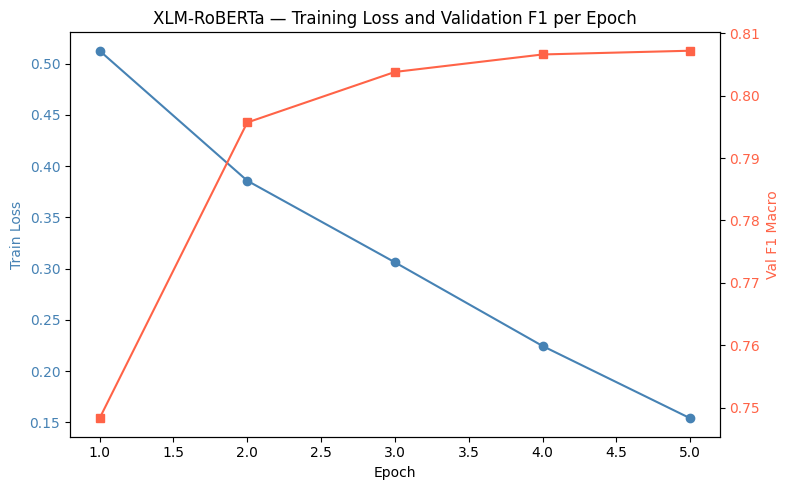

Saved to reports/xlm_roberta_training_curve.png


In [5]:
import json
import matplotlib.pyplot as plt

with open('xlm_roberta_phase1/config.json', 'r') as f:
    config = json.load(f)

training_log = config['training_log']
epochs     = [entry['epoch']      for entry in training_log]
train_loss = [entry['train_loss'] for entry in training_log]
val_f1     = [entry['val_f1']     for entry in training_log]

fig, ax1 = plt.subplots(figsize=(8, 5))

color_loss = 'steelblue'
color_f1   = 'tomato'

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color_loss)
ax1.plot(epochs, train_loss, marker='o', color=color_loss, label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)

ax2 = ax1.twinx()
ax2.set_ylabel('Val F1 Macro', color=color_f1)
ax2.plot(epochs, val_f1, marker='s', color=color_f1, label='Val F1 Macro')
ax2.tick_params(axis='y', labelcolor=color_f1)

plt.title('XLM-RoBERTa — Training Loss and Validation F1 per Epoch')
fig.tight_layout()
plt.savefig('../../reports/xlm_roberta_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to reports/xlm_roberta_training_curve.png")

## 8. Evaluation and Comparison with Baseline

The training log from the previous cell reveals that the loss function was still decreasing in the last epochs, and thus the model could have potentially slightly improved with one or two additional epochs. However, the improvements in the Macro F1 score are becoming much smaller and due to time limitations it was decided to proceed with the current results. 

The best checkpoint (from Epoch 5) is loaded and evaluated on both validation and test sets. Results are compared against the Logistic Regression baseline established in notebook 04.

Note: due to insufficient API scopes on the VM's compute service account at the moment of its creation, BigQuery results could not be written directly from the VM. Instead, results are saved locally as `xlm_roberta_results.json` and uploaded to BigQuery manually from the development laptop. This is a known limitation of the VM configuration and would be resolved in a production setup by creating the VM with all appropriate API scopes enabled at creation time.

In [13]:
# ======================== #
# Evaluation on validation #
# and test sets            #
# ======================== #

from sklearn.metrics import classification_report
from google.cloud import bigquery
import datetime

# --- Load best checkpoint ---
checkpoint = torch.load(f'{CHECKPOINT_DIR}/best_model.pt', map_location=device)
final_model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (Val F1: {checkpoint['val_f1']:.4f})")

# --- Evaluate on val and test ---
results_xlm = {}

for split_name, loader, df in [
    ('val',  val_loader,  val_df),
    ('test', test_loader, test_df)
]:
    final_model.eval()
    all_preds  = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Evaluating {split_name}"):
            input_ids      = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels         = batch['labels']
            logits         = final_model(input_ids=input_ids, attention_mask=attention_mask)
            preds          = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    results_xlm[split_name] = {
        'accuracy':  round(accuracy_score(all_labels, all_preds), 4),
        'precision': round(precision_score(all_labels, all_preds, average='macro'), 4),
        'recall':    round(recall_score(all_labels, all_preds, average='macro'), 4),
        'f1_macro':  round(f1_score(all_labels, all_preds, average='macro'), 4)
    }
    
    print(f"\nXLM-RoBERTa — {split_name.upper()}")
    print(classification_report(all_labels, all_preds, target_names=['No Hate', 'Hate']))

# --- Comparison with baseline ---
print("\n" + "="*70)
print(f"{'Model':<25} {'Split':<6} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("="*70)

baseline = {
    'val':  {'accuracy': 0.776, 'precision': 0.738, 'recall': 0.749, 'f1_macro': 0.743},
    'test': {'accuracy': 0.775, 'precision': 0.739, 'recall': 0.754, 'f1_macro': 0.745}
}

for split in ['val', 'test']:
    m = baseline[split]
    print(f"{'Logistic Regression':<25} {split:<6} {m['accuracy']:>6.3f} {m['precision']:>6.3f} {m['recall']:>6.3f} {m['f1_macro']:>6.3f}")

for split in ['val', 'test']:
    m = results_xlm[split]
    print(f"{'XLM-RoBERTa':<25} {split:<6} {m['accuracy']:>6.3f} {m['precision']:>6.3f} {m['recall']:>6.3f} {m['f1_macro']:>6.3f}")
print("="*70)

# --- Save results locally as JSON ---
import json

results_to_save = []
for split, metrics in results_xlm.items():
    results_to_save.append({
        'model':      'XLM-RoBERTa',
        'split':      split,
        'accuracy':   metrics['accuracy'],
        'precision':  metrics['precision'],
        'recall':     metrics['recall'],
        'f1_macro':   metrics['f1_macro'],
        'created_at': datetime.datetime.now(datetime.timezone.utc).isoformat()
    })

with open('xlm_roberta_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("Results saved to xlm_roberta_results.json")
print("Upload to BigQuery from laptop after downloading this file.")

Loaded best model from epoch 5 (Val F1: 0.8072)


Evaluating val: 100%|████████████████████████████████████████████████████████| 228/228 [00:21<00:00, 10.80it/s]



XLM-RoBERTa — VAL
              precision    recall  f1-score   support

     No Hate       0.88      0.89      0.88      5034
        Hate       0.74      0.73      0.73      2245

    accuracy                           0.84      7279
   macro avg       0.81      0.81      0.81      7279
weighted avg       0.84      0.84      0.84      7279



Evaluating test: 100%|███████████████████████████████████████████████████████| 268/268 [00:24<00:00, 10.78it/s]



XLM-RoBERTa — TEST
              precision    recall  f1-score   support

     No Hate       0.88      0.89      0.89      5922
        Hate       0.75      0.72      0.74      2642

    accuracy                           0.84      8564
   macro avg       0.81      0.81      0.81      8564
weighted avg       0.84      0.84      0.84      8564


Model                     Split     Acc   Prec    Rec     F1
Logistic Regression       val     0.776  0.738  0.749  0.743
Logistic Regression       test    0.775  0.739  0.754  0.745
XLM-RoBERTa               val     0.836  0.809  0.806  0.807
XLM-RoBERTa               test    0.840  0.814  0.807  0.810
Results saved to xlm_roberta_results.json
Upload to BigQuery from laptop after downloading this file.


## 9. Save Model to GCS

The fine-tuned model weights, tokenizer and training configuration are saved to the 
`sinodio-models` bucket under `phase1/xlm_roberta/`. Three files are saved:

- `model_weights.pt`: the PyTorch state dictionary of the fine-tuned model
- `tokenizer.json` and `tokenizer_config.json`: the XLM-RoBERTa tokenizer files 
  needed to preprocess new texts at inference time
- `config.json`: training configuration including best hyperparameters, architecture 
  details and training log

Note: due to the VM's access token scope limitations, the upload could not be performed via the Python `google-cloud-storage` client. Instead, `gcloud storage cp` is used after authenticating with `gcloud auth login`, which bypasses the service account scope restriction. This is another instance of the same infrastructure limitation described in section 8.

In [14]:
# =============================== #
# Save model and tokenizer to GCS #
# sinodio-models bucket           #
# =============================== #

from google.cloud import storage
import os

GCS_MODELS_BUCKET = 'sinodio-models'
models_client = storage.Client()
models_bucket = models_client.bucket(GCS_MODELS_BUCKET)

# --- Save model and tokenizer locally first ---
local_model_dir = 'xlm_roberta_phase1'
os.makedirs(local_model_dir, exist_ok=True)

# Save model weights
torch.save(
    final_model.state_dict(),
    f'{local_model_dir}/model_weights.pt'
)

# Save tokenizer
tokenizer.save_pretrained(local_model_dir)

# Save training config
config = {
    'model_name':    MODEL_NAME,
    'max_length':    MAX_LENGTH,
    'best_epoch':    best_epoch,
    'best_val_f1':   best_val_f1,
    'best_params':   best_params,
    'training_log':  training_log,
    'architecture':  '768 -> 256 -> 2',
    'dropout':       0.3
}

with open(f'{local_model_dir}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Model saved locally.")

# --- Upload to GCS ---
files_to_upload = os.listdir(local_model_dir)

for filename in files_to_upload:
    local_path = f'{local_model_dir}/{filename}'
    blob_path  = f'phase1/xlm_roberta/{filename}'
    blob = models_bucket.blob(blob_path)
    blob.upload_from_filename(local_path)
    print(f"Uploaded {filename} → gs://{GCS_MODELS_BUCKET}/{blob_path}")

print(f"\nModel successfully saved to gs://{GCS_MODELS_BUCKET}/phase1/xlm_roberta/")

Model saved locally.


Forbidden: 403 POST https://storage.googleapis.com/upload/storage/v1/b/sinodio-models/o?uploadType=multipart: {
  "error": {
    "code": 403,
    "message": "Provided scope(s) are not authorized",
    "errors": [
      {
        "message": "Provided scope(s) are not authorized",
        "domain": "global",
        "reason": "forbidden"
      }
    ]
  }
}
: ('Request failed with status code', 403, 'Expected one of', <HTTPStatus.OK: 200>)